In [304]:
#1.데이터를 잘 볼수 있나
#2.트레이닝의 의미를 알고 작업하는지
#3.이미지의 피처 파악

In [305]:
import warnings
warnings.filterwarnings('ignore')

import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [306]:
dirNames=['chair','laptop','piano']

In [307]:
widthRatio=[]
heightRatio=[]

for name in dirNames:
    for file in sorted(glob.glob(f"../Data/ex/{name}/*.jpg")):
        img=np.array(Image.open(file),dtype=np.int32)
        widthRatio.append(img.shape[1])#0=row,height/1=column,width
        heightRatio.append(img.shape[0])#

In [308]:
print("너비 최대 해상도:", np.max(widthRatio))
print("높이 최대 해상도:", np.max(heightRatio))

너비 최대 해상도: 300
높이 최대 해상도: 300


In [ ]:
for name in dirNames:
    fileCount=0
    for file in sorted(glob.glob(f"../Data/ex/{name}/*.jpg")):
        img = Image.open(file)
        img = img.resize((150, 200)) 
        imgArray = np.array(img)

        imgDummy=np.zeros(200*150*3).reshape(200,150,3)
        rowNum=(200-imgArray.shape[0])/2
        colNum=(150-imgArray.shape[1])/2

        k = 0
        for i in range(int(rowNum),int(rowNum)+imgArray.shape[0]):
            l =0
            for j in range(int(colNum),int(colNum+imgArray.shape[1])):
                imgDummy[i,j] = imgArray[k,l]
                l+=1
            k+=1

        img2= Image.fromarray(imgDummy.astype('uint8'))
        # os.makedirs(f"../Data/exColor/{name}", exist_ok=True)

        img2.save(f"../Data/exColor/{name}/image_{fileCount:02}.jpg","JPEG")
        fileCount+=1

In [310]:
number_of_data = 0
for name in dirNames:
    files = sorted(glob.glob(f"../Data/exColor/{name}/*.jpg"))
    number_of_data += len(files)

print("전체 이미지 수:", number_of_data)

전체 이미지 수: 203


In [311]:
# number_of_data= 80*len(dirNames)
# img_width_size=300
# img_height_size=400
# img_color=3

In [312]:
# images = []
# labels = []

In [313]:
# for idx, name in enumerate(dirNames):
#     for file in sorted(glob.glob(f"../Data/exColor/{name}/*.jpg")):
#         img = np.array(Image.open(file), dtype=np.int32)
#         images.append(img)
#         labels.append(idx)

In [314]:
# train = np.array(images, dtype=np.float32)
# target = np.array(labels, dtype=np.int32)

# print(train.shape)
# print(target.shape)

In [315]:
# train=np.zeros(number_of_data*img_width_size*img_height_size*img_color,
#                dtype=np.int32).reshape(number_of_data,img_height_size,img_width_size,img_color)

In [316]:
# img_width_size = 300
# img_height_size = 400
# img_color = 3 

# train = np.zeros(number_of_data * img_width_size * img_height_size * img_color,
#                  dtype=np.int32).reshape(number_of_data, img_height_size, img_width_size, img_color)


In [317]:
img_width_size = 150
img_height_size = 200
img_color = 3
train = np.zeros(number_of_data * img_width_size * img_height_size * img_color,
                 dtype=np.int32).reshape(number_of_data, img_height_size, img_width_size, img_color)

# train = train.reshape(-1, 200, 150, 3) / 255.0
input_shape=(200,150,3)


In [318]:
train

array([[[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        ...,

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]],


       [[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0,

In [319]:
train.shape

(203, 200, 150, 3)

In [ ]:
i=0
for name in dirNames:
    for file in sorted(glob.glob(f"../Data/exColor/{name}/*.jpg")):
        img = np.array(Image.open(file), dtype=np.int32)
        train[i,:,:]=img
        i+=1
train = train / 255.0#이미지 정규화 필요 중앙값으로 바꿔줘야함(색깔 반전)
print(train.shape)

(203, 200, 150, 3)


In [321]:
train.shape

(203, 200, 150, 3)

(200, 150, 3)
float64
0.0 1.0


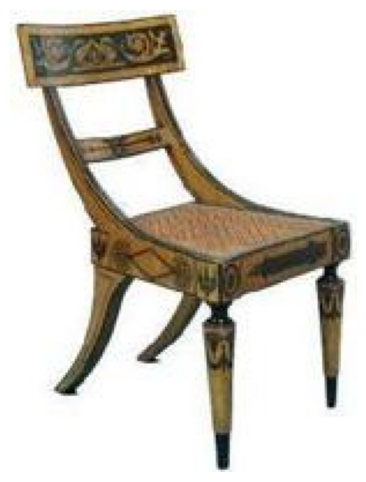

In [322]:
print(train[0].shape)
print(train[0].dtype)
print(np.min(train[0]), np.max(train[0]))

plt.figure(figsize=(6,6))
plt.imshow(train[0])
plt.axis('off')
plt.show()

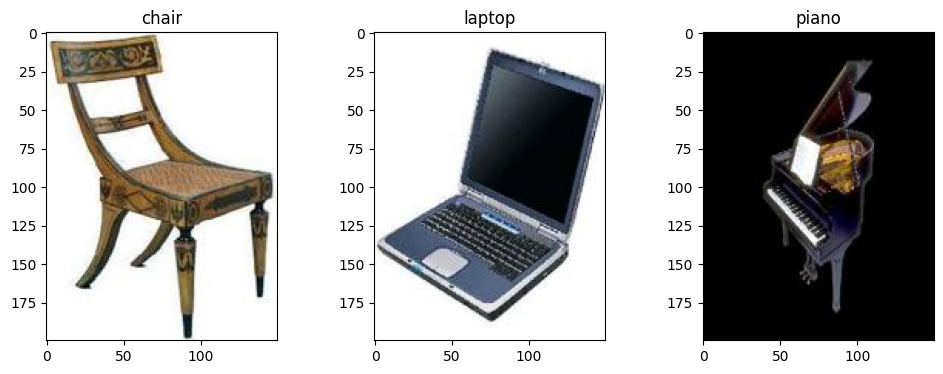

In [323]:
start_idx = 0
plt.figure(figsize=(12,4))

for i, name in enumerate(dirNames):
    plt.subplot(1, len(dirNames), i+1)
    plt.imshow(train[start_idx])
    plt.title(name)

    file_count = len(sorted(glob.glob(f"../Data/exColor/{name}/*.jpg")))
    start_idx += file_count


In [324]:
# plt.figure(figsize=(20,20))
# orderNo=range(0,len(dirNames)*18,18)

# for i in range(1,len(dirNames)+1):
#     plt.subplot(1,len(dirNames),i)
#     plt.imshow(train[orderNo[i-1]].reshape(400,300,3))
#     plt.title(dirNames[i-1])

In [325]:
target_list = []

for idx, name in enumerate(dirNames):
    files = sorted(glob.glob(f"../Data/exColor/{name}/*.jpg"))
    target_list.extend([idx] * len(files))

target = np.array(target_list)
print(target.shape)


(203,)


In [326]:
# target=np.concatenate(
#     [np.zeros(18),np.ones(18),np.full(18,2)]
# )

In [327]:
len(target)

203

In [328]:
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

In [329]:
# train=train.reshape(-1,400,300,3)/255.0

In [330]:
train[:2]

array([[[[1.        , 0.94901961, 0.95294118],
         [1.        , 0.98039216, 0.99215686],
         [1.        , 0.97254902, 0.99215686],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[1.        , 0.98039216, 0.99215686],
         [1.        , 0.95686275, 0.97254902],
         [0.9254902 , 0.90196078, 0.91764706],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[1.        , 0.98823529, 1.        ],
         [1.        , 0.99215686, 1.        ],
         [1.        , 0.99215686, 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        ...,

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]

In [331]:
X_train, X_test, y_train, y_test = train_test_split(
    train, target, test_size=0.2, random_state=42, stratify=target
)

In [332]:
# X_train = X_train / 255.0
# X_test = X_test / 255.0

# CNN 입력 형태: (개수, 32, 32, 1)
# X_train = X_train.reshape(-1, 400, 300, 1)
# X_test = X_test.reshape(-1, 400, 300, 1)

# print("CNN용 X_train shape:", X_train.shape)
# print("CNN용 X_test shape :", X_test.shape)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 200, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 100, 75, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 100, 75, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 100, 75, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 236800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │    15,155,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,248,707 (58.17 MB)

 Trainable params: 15,248,707 (58.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3721 - loss: 3.7629 - val_accuracy: 0.3939 - val_loss: 1.0484
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 584ms/step - accuracy: 0.4419 - loss: 1.0538 - val_accuracy: 0.5758 - val_loss: 0.9893
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 707ms/step - accuracy: 0.5891 - loss: 0.9091 - val_accuracy: 0.5758 - val_loss: 0.9184
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 802ms/step - accuracy: 0.6202 - loss: 0.7781 - val_accuracy: 0.6970 - val_loss: 0.7860
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 854ms/step - accuracy: 0.7287 - loss: 0.6507 - val_accuracy: 0.6364 - val_loss: 0.8235
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 604ms/step - accuracy: 0.7519 - loss: 0.5787 - val_accuracy: 0.6061 - val_loss: 0.8094
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 617ms/step - accuracy: 0.8372 - loss: 0.5125 - val_accuracy: 0.9091 - val_loss: 0.5260
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 618ms/step - accuracy: 0.8605 - loss: 0.2855 - val_accuracy: 0.8788 - val_loss: 0.

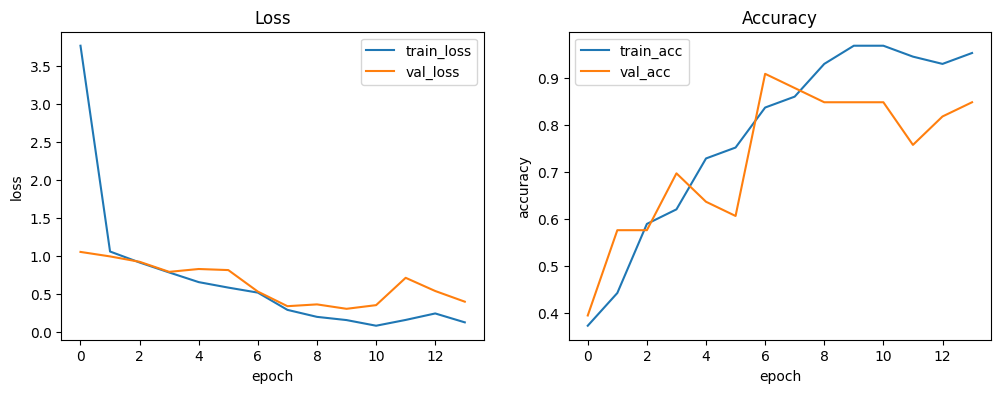

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.9691 - loss: 0.0974
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8485 - loss: 0.2995 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8537 - loss: 0.4870


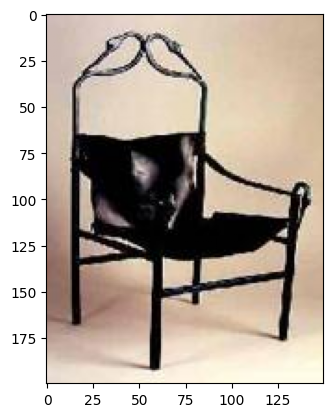

In [333]:
train_input, val_input, train_target, val_target = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = keras.Sequential()

model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same',
    input_shape=(200,150, 3)
))
model.add(keras.layers.MaxPool2D(2))

model.add(keras.layers.Conv2D(
    64,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model.add(keras.layers.Conv2D(
    128,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model.add(keras.layers.MaxPool2D(2))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "../Data/best_model.keras",
    save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_input,
    train_target,
    epochs=20,
    validation_data=(val_input, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

train_loss, train_acc = model.evaluate(X_train, y_train)
val_loss, val_acc = model.evaluate(val_input, val_target)
test_loss, test_acc = model.evaluate(X_test, y_test)

# print("train loss:", train_loss)
# print("train accuracy:", train_acc)
# print("val loss:", val_loss)
# print("val accuracy:", val_acc)
# print("test loss:", test_loss)
# print("test accuracy:", test_acc)

plt.imshow(X_test[0])
plt.show()


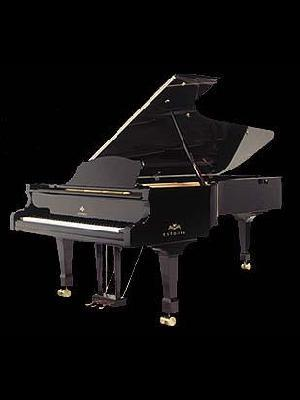

In [334]:
piano = Image.open("../Data/image_08.jpg")
piano

In [335]:
piano.save("../Data/image_081.jpg")

In [336]:
from PIL import ImageDraw
import random

In [337]:
def add_noise(image1, noise_prob=0.01, color=(255,255,255)):#1%,하얀색
    image=image1.copy()
    width,height=image.size
    draw=ImageDraw.Draw(image)
    for x in range(width):
        for y in range(height):
            if random.random()<noise_prob:
             draw.point((x,y), fill=color)

    return image

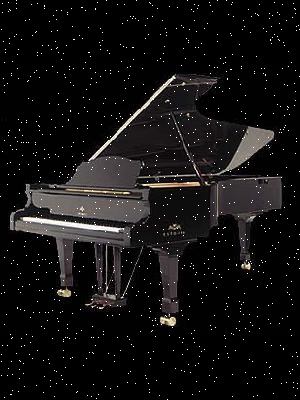

In [338]:
pianoNoise=add_noise(piano)
pianoNoise

In [339]:
counter=0
for angle in range(-15,15,1):#1:30 , 0.5:60
    counter+=1
    img2=piano.rotate(angle)
    img2.save(f"../Data/pianoImage/{counter:03}.png")

    counter+=1
    img3=img2.transpose(Image.FLIP_LEFT_RIGHT)
    img3.save(f"../Data/pianoImage/{counter:03}.png")